In [45]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical

In [46]:
dataset_path = "dataset"

In [47]:
#A filename looks like:03-01-05-02-02-01-12.wav
#The third number represents the emotion.


In [48]:
emotion_dict = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

In [49]:
features = []
labels = []

In [50]:
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)
            emotion_code = file.split("-")[2]
            emotion = emotion_dict[emotion_code]
            audio, sample_rate = librosa.load(file_path, sr=None)
            #MFCC (Mel-Frequency Cepstral Coefficients) is a way to convert sound into numbers that a neural network can understand.
            mfcc = librosa.feature.mfcc(
                y=audio,
                sr=sample_rate,
                n_mfcc=40
            )
            mfcc = mfcc.T
            MAX_LEN = 200
            if mfcc.shape[0] < MAX_LEN:
                pad_width = MAX_LEN - mfcc.shape[0]
                mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode='constant')
            else:
                mfcc = mfcc[:MAX_LEN, :]
            
            if mfcc.shape != (200, 40):
                print(file, mfcc.shape)
                
            features.append(mfcc)
            labels.append(emotion)

In [51]:
shapes = set()

for feature in features:
    shapes.add(feature.shape)

print(shapes)

{(200, 40)}


In [52]:
print(len(features))
print(len(labels))

2880
2880


In [53]:
print(features[0].shape)
print(features[-1].shape)

(200, 40)
(200, 40)


In [54]:
X = np.array(features)
y = np.array(labels)

In [55]:
print(X.shape)
print(y.shape)
print(y[:10])

(2880, 200, 40)
(2880,)
['neutral' 'neutral' 'neutral' 'neutral' 'calm' 'calm' 'calm' 'calm'
 'calm' 'calm']


In [56]:
print(X[0])

[[-8.61532593e+02  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-8.61532593e+02  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-8.61532593e+02  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [-5.75793701e+02  2.09911697e+02  3.10324249e+01 ... -1.23499775e+01
  -1.06260359e+00 -8.29436016e+00]
 [-5.72366089e+02  2.10700699e+02  3.40066299e+01 ... -7.99056625e+00
   7.32124150e-02 -8.10135269e+00]
 [-5.68906250e+02  2.14866608e+02  3.02806511e+01 ... -7.49761724e+00
   7.28463948e-01 -1.16040640e+01]]


In [57]:
print(X[0].size)

8000


In [58]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

In [59]:
print(y[0:10])

[5 5 5 5 1 1 1 1 1 1]


In [60]:
y = to_categorical(y)

In [61]:
print(y[0:10])

[[0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]]


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [63]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2304, 200, 40)
(576, 200, 40)
(2304, 8)
(576, 8)


In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout

In [65]:
model = Sequential()

# CNN Block
model.add(Conv1D(filters=64,kernel_size=3,activation='relu',input_shape=(200, 40)))
model.add(MaxPooling1D(pool_size=2))

# LSTM
model.add(LSTM(64))

# Fully Connected Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(8, activation='softmax'))

e:\DEEP LEARNING\tf-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [66]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [67]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 198, 64)        │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 99, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,448 (177.53 KB)

 Trainable params: 45,448 (177.53 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=65,
    batch_size=32
)

Epoch 1/65
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8537 - loss: 0.4485 - val_accuracy: 0.7465 - val_loss: 0.7204
Epoch 2/65
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8568 - loss: 0.4252 - val_accuracy: 0.7760 - val_loss: 0.7208
Epoch 3/65
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8663 - loss: 0.4214 - val_accuracy: 0.7465 - val_loss: 0.8342
Epoch 4/65
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - accuracy: 0.8377 - loss: 0.4736 - val_accuracy: 0.7760 - val_loss: 0.7085
Epoch 5/65
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.8594 - loss: 0.4372 - val_accuracy: 0.7378 - val_loss: 0.8784
Epoch 6/65
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 68ms/step - accuracy: 0.8264 - loss: 0.4993 - val_accuracy: 0.7292 - val_loss: 0.7668
Epoch 7/65
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.8520 - loss: 0.4406 - val_accuracy: 0.7396 - val_loss: 0.7253
Epoch 8/65
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.8676 - loss: 0.3918 - val_accuracy: 0.756

In [76]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32
)

Epoch 1/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9080 - loss: 0.2825 - val_accuracy: 0.7830 - val_loss: 0.8995
Epoch 2/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9245 - loss: 0.2385 - val_accuracy: 0.8368 - val_loss: 0.6768
Epoch 3/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9262 - loss: 0.2411 - val_accuracy: 0.7830 - val_loss: 0.8433
Epoch 4/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9002 - loss: 0.2853 - val_accuracy: 0.8385 - val_loss: 0.6819
Epoch 5/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9284 - loss: 0.2054 - val_accuracy: 0.8021 - val_loss: 0.7490


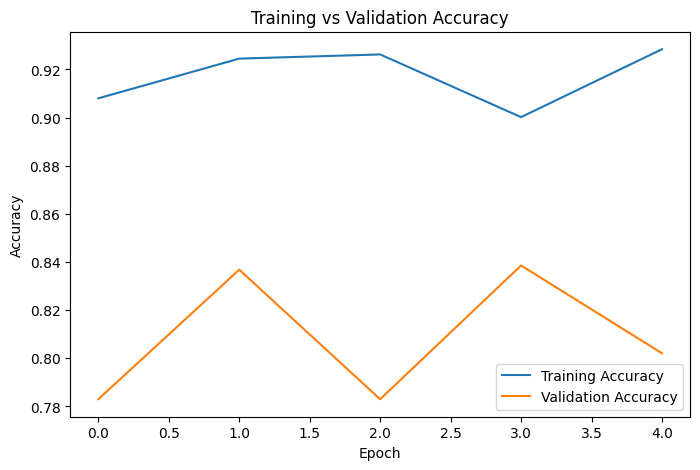

In [77]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

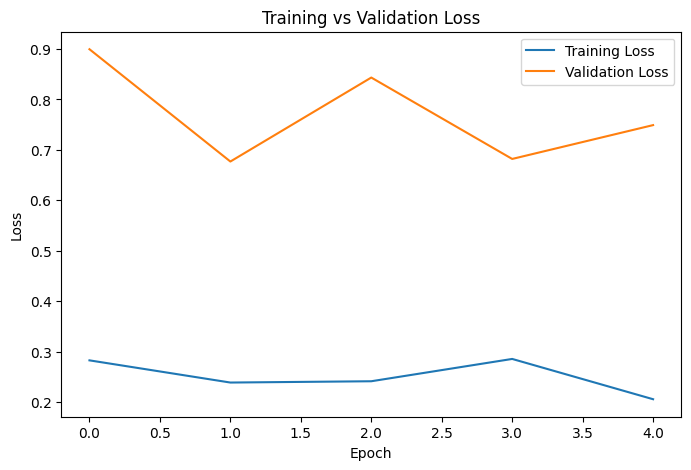

In [78]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [79]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8021 - loss: 0.7490
Test Loss : 0.7489968538284302
Test Accuracy : 0.8020833134651184


In [80]:
model.save("emotion_model.keras")

In [82]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [83]:
y_pred = model.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [84]:
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

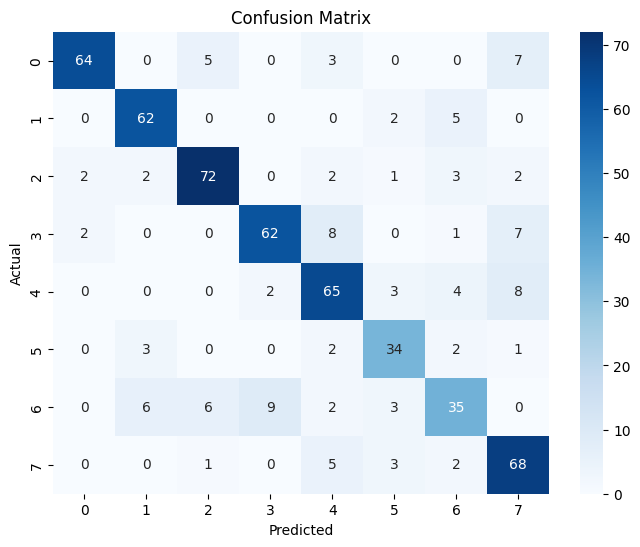

In [85]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [86]:
print(classification_report(
    y_true,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

       angry       0.94      0.81      0.87        79
        calm       0.85      0.90      0.87        69
     disgust       0.86      0.86      0.86        84
     fearful       0.85      0.78      0.81        80
       happy       0.75      0.79      0.77        82
     neutral       0.74      0.81      0.77        42
         sad       0.67      0.57      0.62        61
   surprised       0.73      0.86      0.79        79

    accuracy                           0.80       576
   macro avg       0.80      0.80      0.80       576
weighted avg       0.81      0.80      0.80       576



In [87]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)